In [126]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
# Read in initial data files

# updated the file path  
df_energy = pd.read_csv('../data/raw/energy_dataset.csv')
df_weather = pd.read_csv('../data/raw/weather_features.csv')

# Convert date/time to datetime format
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_weather['dt_iso'] = pd.to_datetime(df_weather['dt_iso'], utc=True)

# Extract date and hour for each dataframe
df_energy.insert(1, 'date', df_energy['time'].dt.date)
df_energy.insert(2, 'hour', df_energy['time'].dt.hour)


### Drop all the columns that have all zeroes and NaNs, as they are unusable 

In [128]:
### print out columns with all zero or all NaN values 
n = len(df_energy)
for col in df_energy.columns:
    n_zero = (df_energy[col] == 0).sum()
    n_nan  = df_energy[col].isna().sum()
    if n_zero + n_nan == n:
        print(f"{col}: {n_zero} zero / {n_nan} NaN / {n} total")



### save in a list of columns to drop 

useless_cols = [
    col for col in df_energy.columns
    if (df_energy[col] == 0).sum() + df_energy[col].isna().sum() == n
]

### drop columns 
df_energy = df_energy.drop(useless_cols, axis=1)


generation fossil coal-derived gas: 35046 zero / 18 NaN / 35064 total
generation fossil oil shale: 35046 zero / 18 NaN / 35064 total
generation fossil peat: 35046 zero / 18 NaN / 35064 total
generation geothermal: 35046 zero / 18 NaN / 35064 total
generation hydro pumped storage aggregated: 0 zero / 35064 NaN / 35064 total
generation marine: 35045 zero / 19 NaN / 35064 total
generation wind offshore: 35046 zero / 18 NaN / 35064 total
forecast wind offshore eday ahead: 0 zero / 35064 NaN / 35064 total


In [129]:
df_energy.head()

,time,date,hour,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,...,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 23:00:00+00:00,2014-12-31,23,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,...,73.0,49.0,196.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 00:00:00+00:00,2015-01-01,0,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,...,71.0,50.0,195.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 01:00:00+00:00,2015-01-01,1,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,...,73.0,50.0,196.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 02:00:00+00:00,2015-01-01,2,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,...,75.0,50.0,191.0,5238.0,2.0,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 03:00:00+00:00,2015-01-01,3,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,...,74.0,42.0,189.0,4935.0,9.0,4861.0,21785.0,20264.0,38.41,56.04


In [130]:
df_energy.describe().round(2)

,hour,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35064.00,35045.00,35046.00,35046.00,35046.00,35045.00,35045.00,35045.00,35046.00,35047.00,...,35046.00,35046.00,35045.00,35046.00,35064.00,35064.00,35064.00,35028.00,35064.00,35064.00
mean,11.50,383.51,448.06,5622.74,4256.07,298.32,475.58,972.12,2605.11,6263.91,...,85.64,1432.67,269.45,5464.48,1439.07,5471.22,28712.13,28696.94,49.87,57.88
std,6.92,85.35,354.57,2201.83,1961.60,52.52,792.41,400.78,1835.20,839.67,...,14.08,1680.12,50.20,3213.69,1677.70,3176.31,4594.10,4574.99,14.62,14.20
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,237.00,18105.00,18041.00,2.06,9.33
25%,5.75,333.00,0.00,4126.00,2527.00,263.00,0.00,637.00,1077.25,5760.00,...,73.00,71.00,240.00,2933.00,69.00,2979.00,24793.75,24807.75,41.49,49.35
50%,11.50,367.00,509.00,4969.00,4474.00,300.00,68.00,906.00,2164.00,6566.00,...,88.00,616.00,279.00,4849.00,576.00,4855.00,28906.00,28901.00,50.52,58.02
75%,17.25,433.00,757.00,6429.00,5838.75,330.00,616.00,1250.00,3757.00,7025.00,...,97.00,2578.00,310.00,7398.00,2636.00,7353.00,32263.25,32192.00,60.53,68.01
max,23.00,592.00,999.00,20034.00,8359.00,449.00,4523.00,2000.00,9728.00,7117.00,...,119.00,5792.00,357.00,17436.00,5836.00,17430.00,41390.00,41015.00,101.99,116.80


### Check for NaN & duplicate values 

In [131]:
df_energy.isna().sum()

time                                            0
date                                            0
hour                                            0
generation biomass                             19
generation fossil brown coal/lignite           18
generation fossil gas                          18
generation fossil hard coal                    18
generation fossil oil                          19
generation hydro pumped storage consumption    19
generation hydro run-of-river and poundage     19
generation hydro water reservoir               18
generation nuclear                             17
generation other                               18
generation other renewable                     18
generation solar                               18
generation waste                               19
generation wind onshore                        18
forecast solar day ahead                        0
forecast wind onshore day ahead                 0
total load forecast                             0


In [132]:
### check for duplicates  
df_energy.duplicated().any()


np.False_

### Visualize some of the generation data to see if there are any trends and help inform our interpolation method 

In [133]:
### function to visualize a sample of the data for a given column and time range 
def plot_column(df, col, start=None, end=None):
    mask = pd.Series(True, index=df.index)
    if start:
        mask &= df['time'] >= pd.Timestamp(start, tz='UTC')
    if end:
        mask &= df['time'] <= pd.Timestamp(end, tz='UTC')
    
    subset = df[mask]
    
    plt.figure(figsize=(14, 4))
    plt.plot(subset['time'], subset[col])
    plt.title(col)
    plt.xlabel('time')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### Missing data - generation biomass 

In [134]:
df_energy[df_energy['generation biomass'].isna()]

,time,date,hour,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,...,generation other renewable,generation solar,generation waste,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
99,2015-01-05 02:00:00+00:00,2015-01-05,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,546.0,8233.0,21912.0,21182.0,35.20,59.68
108,2015-01-05 11:00:00+00:00,2015-01-05,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3932.0,9258.0,23209.0,NaN,35.50,79.14
109,2015-01-05 12:00:00+00:00,2015-01-05,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4236.0,9156.0,23725.0,NaN,36.80,73.95
110,2015-01-05 13:00:00+00:00,2015-01-05,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4215.0,9072.0,23614.0,NaN,32.50,71.93
111,2015-01-05 14:00:00+00:00,2015-01-05,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4050.0,8779.0,22381.0,NaN,30.00,71.50
112,2015-01-05 15:00:00+00:00,2015-01-05,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3728.0,8426.0,21371.0,NaN,30.00,71.85
113,2015-01-05 16:00:00+00:00,2015-01-05,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,3175.0,7946.0,20760.0,NaN,30.60,80.53
451,2015-01-19 18:00:00+00:00,2015-01-19,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,91.0,6434.0,38642.0,39304.0,70.01,88.95
452,2015-01-19 19:00:00+00:00,2015-01-19,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,28.0,6907.0,38758.0,39262.0,69.00,87.94
643,2015-01-27 18:00:00+00:00,2015-01-27,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,182.0,9807.0,38968.0,38335.0,66.00,83.97


In [135]:
### Most of the NaNs for the generation data occur at the same timestamps (so we can handle them in a similar manner)

####  just focusing on 2015-01-05 since it had consecutive NaNs 

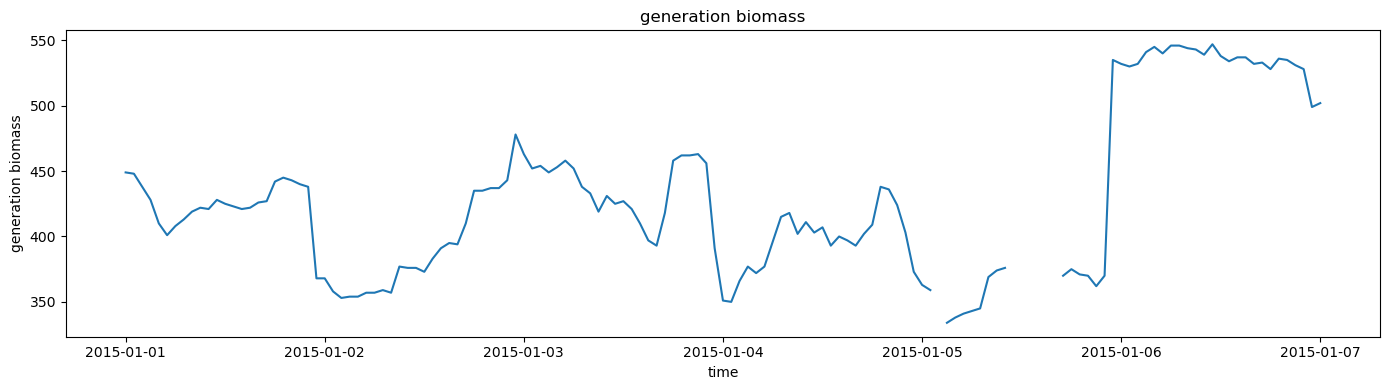

In [136]:
plot_column(df_energy, 'generation biomass', start='2015-01-01', end='2015-01-07')

In [137]:
df_energy[df_energy['time']>= '2015-01-05'][['time', 'generation biomass']].head(40)

,time,generation biomass
97,2015-01-05 00:00:00+00:00,363.0
98,2015-01-05 01:00:00+00:00,359.0
99,2015-01-05 02:00:00+00:00,NaN
100,2015-01-05 03:00:00+00:00,334.0
101,2015-01-05 04:00:00+00:00,338.0
102,2015-01-05 05:00:00+00:00,341.0
103,2015-01-05 06:00:00+00:00,343.0
104,2015-01-05 07:00:00+00:00,345.0
105,2015-01-05 08:00:00+00:00,369.0
106,2015-01-05 09:00:00+00:00,374.0


In [138]:
### not too much variation so regular interpolation should be sufficient 

### Missing Load Data 

In [139]:
df_energy[df_energy['total load actual'].isna()][['time', 'date', 'hour', 'generation biomass', 'total load actual']]

,time,date,hour,generation biomass,total load actual
108,2015-01-05 11:00:00+00:00,2015-01-05,11,NaN,NaN
109,2015-01-05 12:00:00+00:00,2015-01-05,12,NaN,NaN
110,2015-01-05 13:00:00+00:00,2015-01-05,13,NaN,NaN
111,2015-01-05 14:00:00+00:00,2015-01-05,14,NaN,NaN
112,2015-01-05 15:00:00+00:00,2015-01-05,15,NaN,NaN
113,2015-01-05 16:00:00+00:00,2015-01-05,16,NaN,NaN
661,2015-01-28 12:00:00+00:00,2015-01-28,12,NaN,NaN
751,2015-02-01 06:00:00+00:00,2015-02-01,6,449.0,NaN
752,2015-02-01 07:00:00+00:00,2015-02-01,7,453.0,NaN
753,2015-02-01 08:00:00+00:00,2015-02-01,8,452.0,NaN


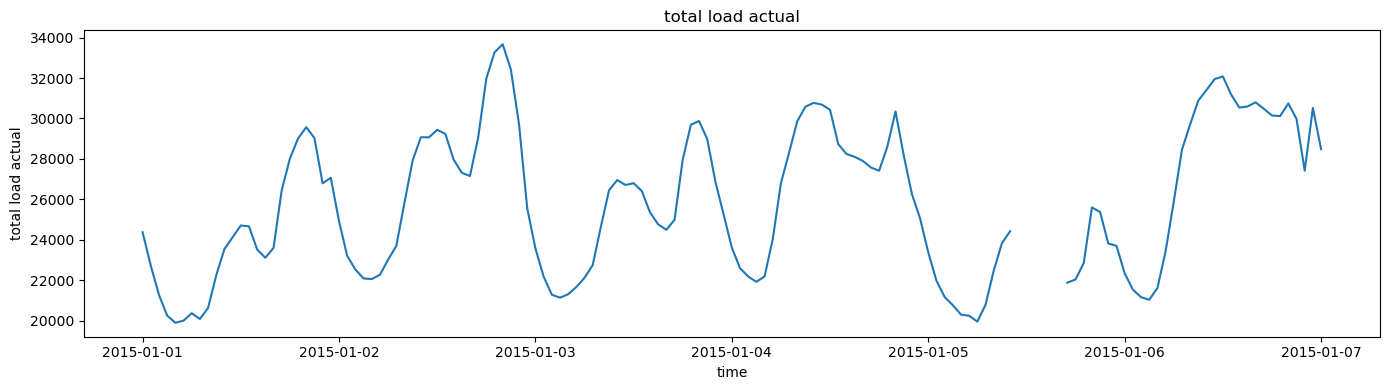

In [140]:
plot_column(df_energy, 'total load actual', start='2015-01-01', end='2015-01-07')

In [141]:
df_energy[df_energy['time']>= '2015-01-05'][['time', 'total load actual']].head(40)

,time,total load actual
97,2015-01-05 00:00:00+00:00,23390.0
98,2015-01-05 01:00:00+00:00,21988.0
99,2015-01-05 02:00:00+00:00,21182.0
100,2015-01-05 03:00:00+00:00,20778.0
101,2015-01-05 04:00:00+00:00,20309.0
102,2015-01-05 05:00:00+00:00,20252.0
103,2015-01-05 06:00:00+00:00,19964.0
104,2015-01-05 07:00:00+00:00,20796.0
105,2015-01-05 08:00:00+00:00,22478.0
106,2015-01-05 09:00:00+00:00,23834.0


In [142]:
### not too much variation between missing values as well 

### Perform linear interpolation to clean up dataset 

In [143]:
df_energy = df_energy.interpolate(method='linear', limit_direction='forward')

df_energy.isna().sum()


/var/folders/m4/6b7dpkcs3xb364c81q1s4_b00000gn/T/ipykernel_40244/2840402740.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_energy = df_energy.interpolate(method='linear', limit_direction='forward')


time                                           0
date                                           0
hour                                           0
generation biomass                             0
generation fossil brown coal/lignite           0
generation fossil gas                          0
generation fossil hard coal                    0
generation fossil oil                          0
generation hydro pumped storage consumption    0
generation hydro run-of-river and poundage     0
generation hydro water reservoir               0
generation nuclear                             0
generation other                               0
generation other renewable                     0
generation solar                               0
generation waste                               0
generation wind onshore                        0
forecast solar day ahead                       0
forecast wind onshore day ahead                0
total load forecast                            0
total load actual   

In [144]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 23 columns):
 #   Column                                       Non-Null Count  Dtype              
---  ------                                       --------------  -----              
 0   time                                         35064 non-null  datetime64[ns, UTC]
 1   date                                         35064 non-null  object             
 2   hour                                         35064 non-null  int32              
 3   generation biomass                           35064 non-null  float64            
 4   generation fossil brown coal/lignite         35064 non-null  float64            
 5   generation fossil gas                        35064 non-null  float64            
 6   generation fossil hard coal                  35064 non-null  float64            
 7   generation fossil oil                        35064 non-null  float64            
 8   generation hydro pumped st

### Save to processed folder 

In [145]:
df_energy.to_csv('data/processed/energy_dataset_clean.csv', index=False)